In [42]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [43]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    build_elements,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average, 
    results2gmsh,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d, plot_gmsh_mesh,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, N , mm, 
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [44]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [45]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'batman'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [46]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=15,
                material=Steel)

# Dictionaries
section_dictionary={17:F1,
                        }

restrain_dictionary={18:['r', 'f']}

load_dictionary = {
                19:   {'value': 10, 'direction': 'x'},   
                20:   {'value': 10, 'direction': '-x'},   

}

In [47]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (2681 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        -1.0000         1.0000         0.0000
       2        -0.7500         3.0000         0.0000
       3        -0.5000         2.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      18      0   'support'
      19      1   'load_p_x'
      20      1   'load_m_x'
      17      2   'steel'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      18      0       15          1            2   'su

In [48]:
# Initialize nodes and apply Dirichlet (restraints) and Neumann (nodal loads) boundary conditions.
mesh.apply_boundary_conditions(restrain_dictionary, load_dictionary, section_dictionary, verbose=True)


  === BOUNDARY CONDITIONS ===
  Nodes created  : 2681
  system_nDof    : 5362

  --- Restrained nodes ---
     Tag              x              y   Restraints
--------------------------------------------------------------------------------
       4         0.0000         2.2500   ['r', 'f']
       9         0.0000        -3.0000   ['r', 'f']
--------------------------------------------------------------------------------

  --- Loaded nodes (dim=0) ---
     Tag              x              y             Fx             Fy
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------

  --- Sections ---
   Phys ID                   Name      Thickness              E       nu
--------------------------------------------------------------------------------
        17                     F1             15      2000.0000    0.300
-----------------------------------------------------------------

In [49]:
system_nDof = mesh.system_nDof
node_map = mesh.node_map

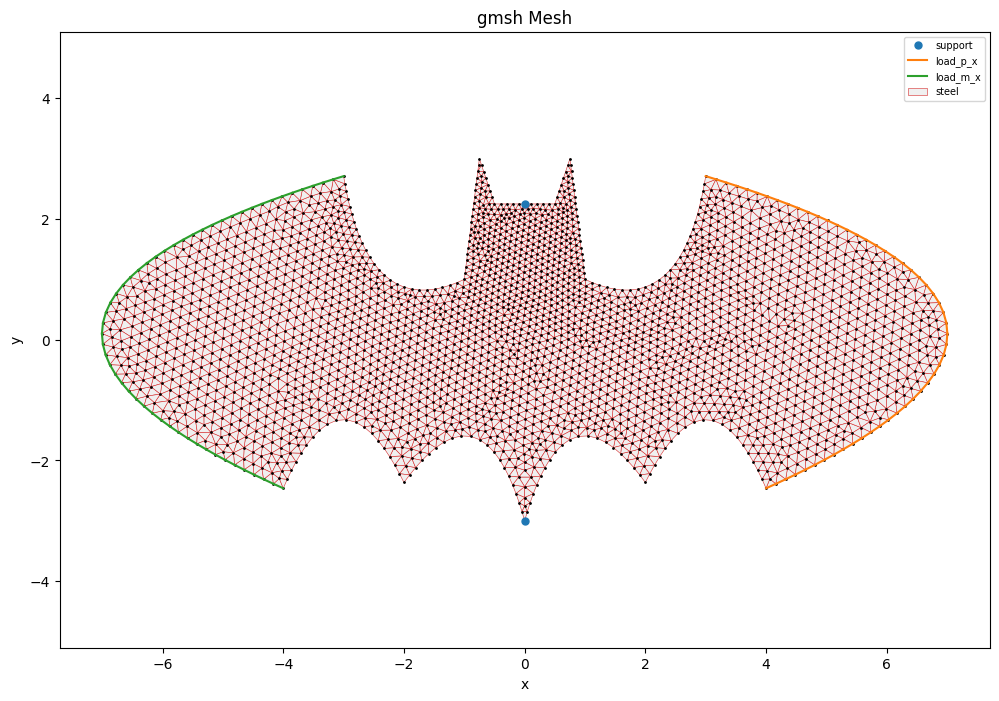

In [50]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = True,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [51]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

elements = build_elements(
    mesh               = mesh,
    node_map           = node_map,
    section_dictionary = section_dictionary,
    element_class_map  = element_map,
    load_dictionary    = load_dictionary,
    type               = 'planeStrain',
    sampling_points    = 3,
    eval_points        = [0, 0],
)

In [52]:
# build lumped nodal force vector
F_nodal = mesh.build_load_vector(load_dictionary)

# assemble to global vector
F_load = np.zeros(mesh.system_nDof)
for tag, f_vec in F_nodal.items():
    if tag in mesh.node_map:
        F_load[mesh.node_map[tag].idx[:len(f_vec)]] += f_vec
F_load[np.abs(F_load) < 1e-4] = 0.0

In [53]:
# # assemble consistent load vector
# F_load = np.zeros(mesh.system_nDof)
# for node in mesh.node_map.values():
#     F_load[node.idx] += node.nodalLoad  
# for elem in elements:
#     F_load[elem.idx] += elem.F_fe_global 
# F_load[np.abs(F_load) < 1e-4] = 0.0

In [54]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = F_load.copy()

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [55]:
# # Reactions per node
# for node in node_map.values():
#     if any(r == 'r' for r in node.restrain):
#         r = R[node.idx]
#         print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

----------------------------------------------------------------------------------------------------
Applied X:  -0.0000   Reaction X: -0.0000   Balance: -1.2324e-10
Applied Y:  +0.0000   Reaction Y: +0.0000   Balance: 0.0000e+00


In [56]:
for node in node_map.values():
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 11 at [-4.       -2.461955]:  Fx=-13.4367  Fy=+0.0000
Node 12 at [ 4.       -2.461955]:  Fx=+13.4367  Fy=+0.0000
Node 13 at [-3.        2.710524]:  Fx=-13.4368  Fy=+0.0000
Node 14 at [3.       2.710524]:  Fx=+13.4368  Fy=+0.0000
Node 119 at [-3.171265  2.657935]:  Fx=-26.8733  Fy=+0.0000
Node 120 at [-3.342141  2.604105]:  Fx=-26.8734  Fy=+0.0000
Node 121 at [-3.512599  2.548956]:  Fx=-26.8733  Fy=+0.0000
Node 122 at [-3.682593  2.492408]:  Fx=-26.8732  Fy=+0.0000
Node 123 at [-3.852086  2.434365]:  Fx=-26.8733  Fy=+0.0000
Node 124 at [-4.021023  2.374727]:  Fx=-26.8733  Fy=+0.0000
Node 125 at [-4.189349  2.31338 ]:  Fx=-26.8734  Fy=+0.0000
Node 126 at [-4.356992  2.250196]:  Fx=-26.8731  Fy=+0.0000
Node 127 at [-4.523875  2.185035]:  Fx=-26.8732  Fy=+0.0000
Node 128 at [-4.689908  2.117731]:  Fx=-26.8732  Fy=+0.0000
Node 129 at [-4.854978  2.048104]:  Fx=-26.8730  Fy=+0.0000
Node 130 at [-5.018956  1.975943]:  Fx=-26.8730  Fy=+0.0000
Node 131 at [-5.181685  1.901008]:  Fx=-26.872

In [57]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [58]:
results2gmsh(
    output_file       = output_file,
    mesh              = mesh,
    node_tags         = node_tags,
    element_tags_list = element_tags_list,
    u_3d              = u_3d,
    F_3d              = F_3d,
    R_3d              = R_3d,
    sigma_gmsh        = sigma_gmsh,
    epsilon_gmsh      = epsilon_gmsh,
    von_mises_gmsh    = von_mises_gmsh,
    disp_factor       = 50,
    show_disp         = True,
    show_loads        = True,
    show_reactions    = True,
    show_stress       = True,
    show_strain       = True,
    show_vm           = True,
    show_averaged     = True,
)

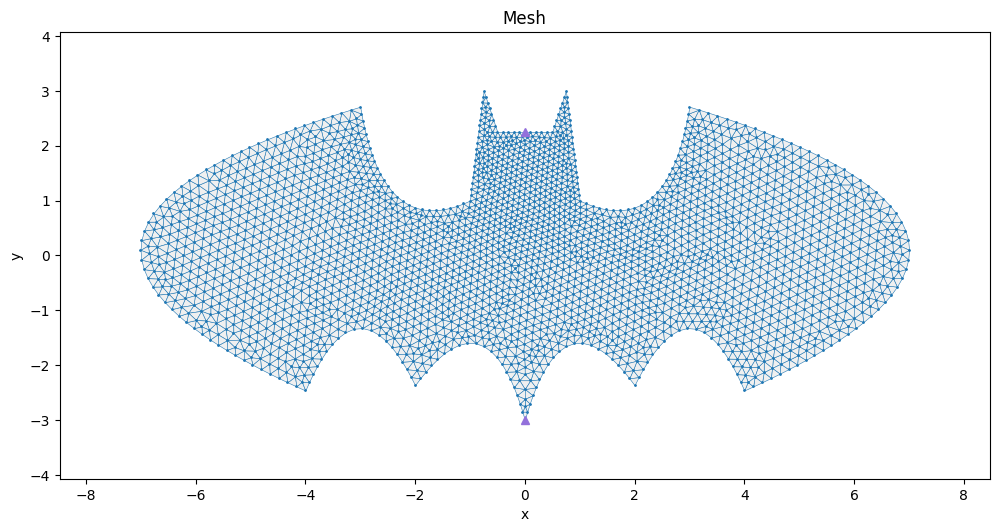

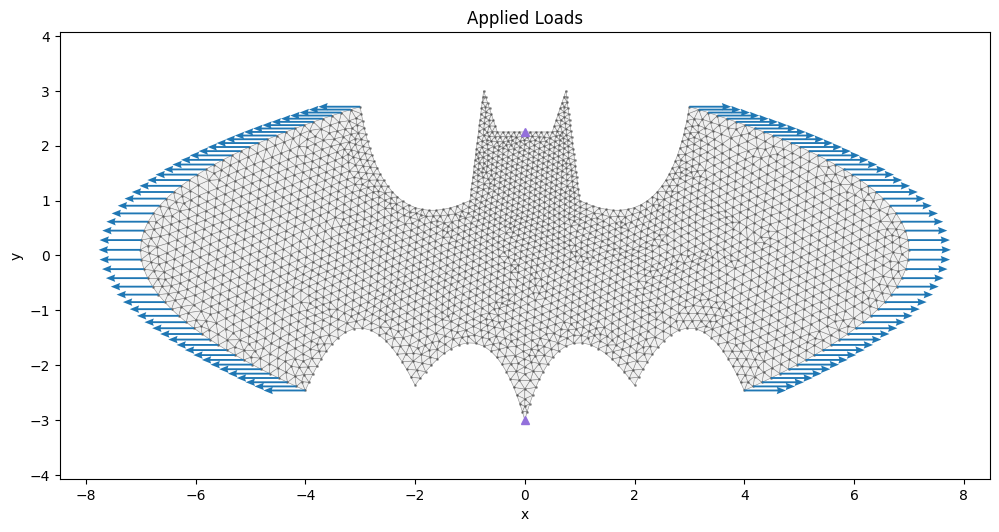

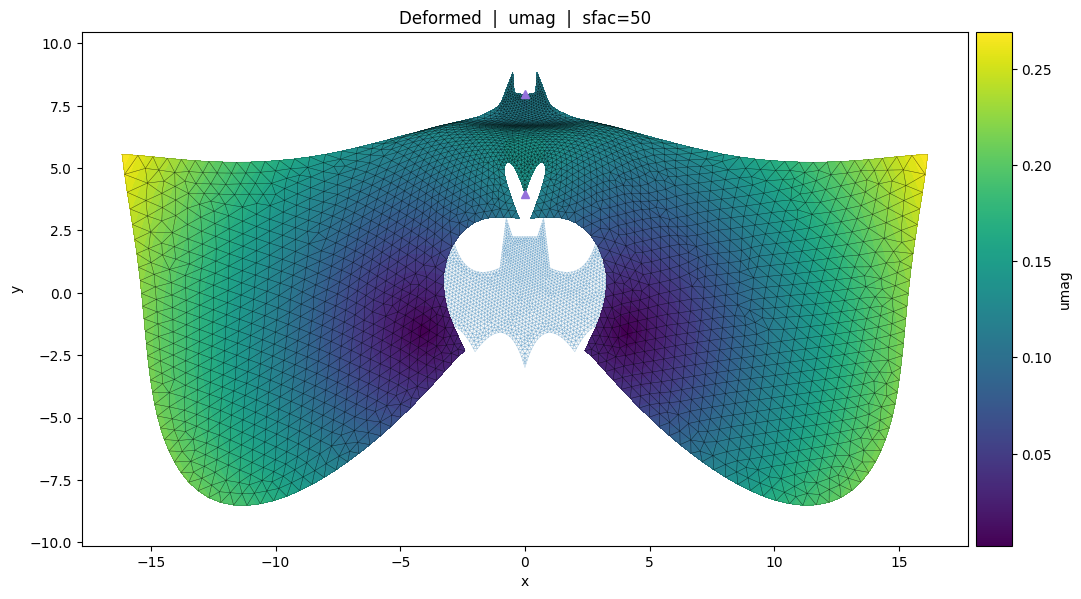

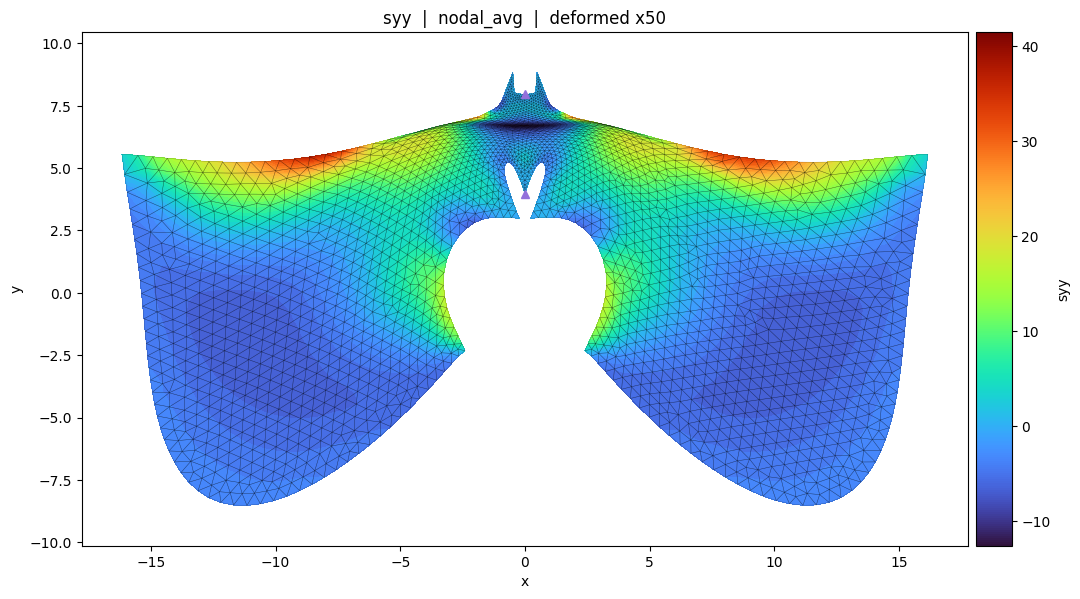

In [60]:
# Mesh
plot_mesh(
    nodes               = node_map.values(),
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Loads
plot_loads_2d(
    nodes               = node_map.values(),
    elements            = elements,
    F_load              = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Deformed
plot_deformed(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    sfac                = 50,
    cmap                = 'viridis',
    limit               = None,
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'syy',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type         = 'nodal_avg', # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    limit               = None,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)